<a href="https://colab.research.google.com/github/dee1empire/-ITAI-1371-ML-Labs-/blob/main/Copy_of_ITAI_1371_Mod_3F1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
wine_data = load_wine()
from sklearn.datasets import load_wine, make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
X, y = wine_data.data, wine_data.target

# Set style for better-looking plots
plt.style.use('default')
sns.set_palette('husl')

print('All libraries imported successfully!')
print('Ready to start our machine learning journey!')



All libraries imported successfully!
Ready to start our machine learning journey!


In [ ]:
# Load the Wine dataset
wine_data = load_wine()

# Convert to DataFrame for easier handling
df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)
df['wine_class'] = wine_data.target
df['wine_class_name'] = [wine_data.target_names[i] for i in wine_data.target]

print('---Dataset Information---')
print(f"Shape: {df.shape}")
print(f'Features: {len(wine_data.feature_names)}')
print(f'Classes: {wine_data.target_names}')
print(f'First 5 rows')
print(df.head())

---Dataset Information---
Shape: (178, 15)
Features: 13
Classes: ['class_0' 'class_1' 'class_2']
First 5 rows
   alcohol  malic_acid   ash  ...  proline  wine_class  wine_class_name
0    14.23        1.71  2.43  ...   1065.0           0          class_0
1    13.20        1.78  2.14  ...   1050.0           0          class_0
2    13.16        2.36  2.67  ...   1185.0           0          class_0
3    14.37        1.95  2.50  ...   1480.0           0          class_0
4    13.24        2.59  2.87  ...    735.0           0          class_0

[5 rows x 15 columns]


In [ ]:
# Explore the dataset structure
print('Dataset Overview')
print("* 50")
print(f"Total samples: {len(df)}")
print(f"Features (input variables): {len(df.columns) -2}") # -2 for target columns
print(f"Target classes: {df['wine_class_name'].unique()}")
print('Class distribution')
print(df['wine_class_name'].value_counts())

# Check for missing values
print('Missing values: {df.insull().sum().sum()}')
print("No missing values - this is a clean dataset!")

Dataset Overview
* 50
Total samples: 178
Features (input variables): 13
Target classes: [np.str_('class_0') np.str_('class_1') np.str_('class_2')]
Class distribution
wine_class_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64
Missing values: {df.insull().sum().sum()}
No missing values - this is a clean dataset!


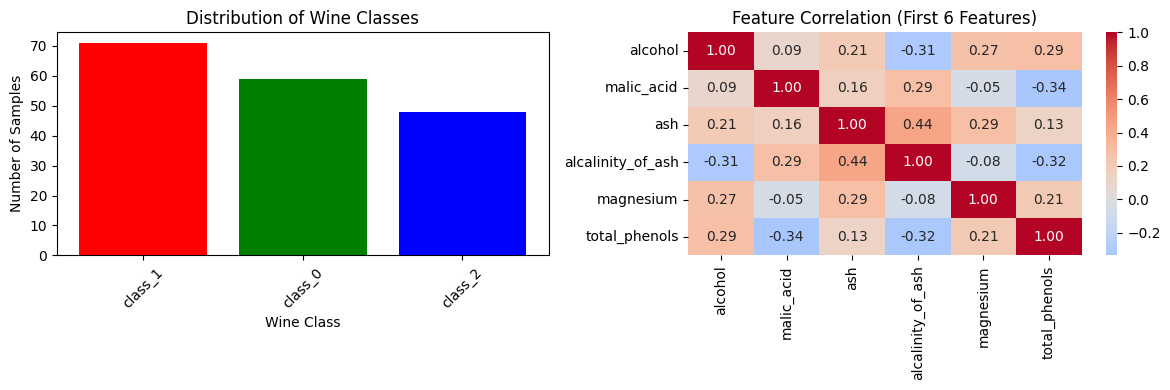

EDA helps us understand:
Class balance (are all classes equally represented?)
Feature relationships (which features are correlated?)
Data quality (any outliers or issues?)


In [ ]:
# Visual class distribution
plt.figure(figsize=(12, 4))

# Subplot 1: Class distribution
plt.subplot(1, 2, 1)
class_counts = df['wine_class_name'].value_counts()
plt.bar(class_counts.index, class_counts.values, color=['red', 'green', 'blue'])
plt.title('Distribution of Wine Classes')
plt.xlabel('Wine Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)

# Subplot 2: Feature correlation heatmap (first 6 features for clarity)
plt.subplot(1, 2, 2)
correlation_matrix = df.iloc[:, :6].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Feature Correlation (First 6 Features)')

plt.tight_layout()
plt.show()

print('EDA helps us understand:')
print('Class balance (are all classes equally represented?)')
print('Feature relationships (which features are correlated?)')
print('Data quality (any outliers or issues?)')

In [ ]:
# Step 1: Data Preparation
print("Step 1: Data Preparation")
print("=" * 30)

# Select features (X) and target (y)
# For simplicity, let's use the first 4 features
feature_names = ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash']
X = df[feature_names]
y = df['wine_class']

print('Selected features: {feature_names}')
print('Feature matrix shape: {X.shape}')
print('Target vector shape: {y.shape}')

# Display first few rows
print('First 5 samples:')
print(X.head())

Step 1: Data Preparation
Selected features: {feature_names}
Feature matrix shape: {X.shape}
Target vector shape: {y.shape}
First 5 samples:
   alcohol  malic_acid   ash  alcalinity_of_ash
0    14.23        1.71  2.43               15.6
1    13.20        1.78  2.14               11.2
2    13.16        2.36  2.67               18.6
3    14.37        1.95  2.50               16.8
4    13.24        2.59  2.87               21.0


In [ ]:
# Step 2: Data Splitting
print('Step 2: Data Splitting')
print('=\' * 30')

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

print('Training set: {X_train.shape[0]} samples')
print('Testing set: {X_test.shape[0]} samples')
print('Training classes: {np.bincount(y_train)}')
print('Testing classes: {np.bincount(y_test)}')

print('Why split data?')
print('-Training set: Teach the model')
print('-Testing set: Evaluate performance on unseen data')
print('-This prevents overfitting (memorizing vs. learning)')


Step 2: Data Splitting
=' * 30
Training set: {X_train.shape[0]} samples
Testing set: {X_test.shape[0]} samples
Training classes: {np.bincount(y_train)}
Testing classes: {np.bincount(y_test)}
Why split data?
-Training set: Teach the model
-Testing set: Evaluate performance on unseen data
-This prevents overfitting (memorizing vs. learning)


In [ ]:
# Step 3: Model Training
print('Step 3: Model Training')
print('* 30')

# Create and train two different models
models = {
'Logistic Regression': LogisticRegression(random_state=42),
'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=3)}

trained_models = {}

for name, model in models.items():
  print('Training {name}...')

# Train the model
model.fit(X_train, y_train)
trained_models[name] = model

print('{name} training completed!')

print('What happened during training?')
print('- Models learned patterns from training data')
print('- They found relationships between features and wine classes')
print('- Now they can make predictions on new data!')

Step 3: Model Training
* 30
Training {name}...
Training {name}...
{name} training completed!
What happened during training?
- Models learned patterns from training data
- They found relationships between features and wine classes
- Now they can make predictions on new data!


In [ ]:
# Step 4: Model Evaluation
print('Step 4: Model Evaluation')
print('* 30')

results = {}

for name, model in trained_models.items():
  # Make predictions
  y_pred = model.predict(X_test)

  # Calculate accuracy
  accuracy = accuracy_score(y_test, y_pred)
  results[name] = accuracy

  print(f'{name} Results:')
  print(f'Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)')

  # Detailed classification report
  print('Detailed Performance:')
  print(classification_report(y_test, y_pred, target_names=wine_data.target_names))

  # Compare models
  print('Model Comparison:')
  for name, accuracy in results.items():
    print(f'{name}: Accuracy {accuracy:.3f}')

    best_model = max(results, key=results.get)
  print(f'Best performing model: {best_model}')

Step 4: Model Evaluation
* 30
Decision Tree Results:
Accuracy: 0.833 (83.3%)
Detailed Performance:
              precision    recall  f1-score   support

     class_0       0.86      1.00      0.92        12
     class_1       0.91      0.71      0.80        14
     class_2       0.73      0.80      0.76        10

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36

Model Comparison:
Decision Tree: Accuracy 0.833
Best performing model: Decision Tree


Step 5: Model Interpretation
* 30


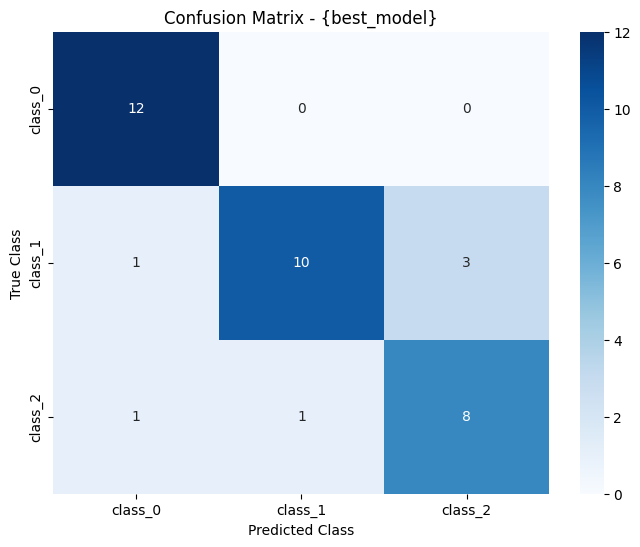

Interpreting the Confusion Matrix:
- Diagonal values: Correct predictions
- Off-diagonal values: Misclassifications
- Perfect model would have all values on diagonal


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Step 5: Model Interpretation
print('Step 5: Model Interpretation')
print ('* 30')

# Visualize confusion matrix for the best model
best_model_obj = trained_models[best_model]

y_pred_best = best_model_obj.predict(X_test)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine_data.target_names,
            yticklabels=wine_data.target_names)

plt.title('Confusion Matrix - {best_model}')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

print(f'Interpreting the Confusion Matrix:')
print('- Diagonal values: Correct predictions')
print('- Off-diagonal values: Misclassifications')
print('- Perfect model would have all values on diagonal')

In [ ]:
# Understanding Different Data Types in ML
print('Understanding Different Data Types in ML')
print('* 45')

# Create examples of different data types
data_examples = {
    'Numerical (Continuous)': [23.5, 45.2, 67.8, 12.1, 89.3],
    'Numerical (Discrete)': [1, 5, 3, 8, 2],
    'Categorical (Nominal)': ['Red', 'Blue', 'Green', 'Red', 'Blue'],
    'Categorical (Ordinal)': ['Low', 'Medium', 'High', 'Medium', 'Low'],
    'Text': ['Hello world', 'Machine learning', 'Data science', 'Python', 'AI revolution'],
    'Boolean': [True, False, True, True, False]}

for data_type, examples in data_examples.items():
        print(f'{data_type}:')
        print(f'Examples: {examples}')
        print(f'Use case:, end=\"')

        if 'Continuous' in data_type:
            print('Regression problems (predicting prices, temperatures)')
        elif 'Discrete' in data_type:
            print('Counting problems (number of items, ratings)')
        elif 'Nominal' in data_type:
            print('Classification without order (colors, categories)')
        elif 'Ordinal' in data_type:
            print('Classification with order (ratings, sizes)')
        elif 'Text' in data_type:
            print('Natural language processing (sentiment analysis, translation)')
        elif 'Boolean' in data_type:
            print('Binary classification (yes/no, spam/not spam)')

            print('Key Insight: Different data types require different preprocessing and algorithms!')



Understanding Different Data Types in ML
* 45
Numerical (Continuous):
Examples: [23.5, 45.2, 67.8, 12.1, 89.3]
Use case:, end="
Regression problems (predicting prices, temperatures)
Numerical (Discrete):
Examples: [1, 5, 3, 8, 2]
Use case:, end="
Counting problems (number of items, ratings)
Categorical (Nominal):
Examples: ['Red', 'Blue', 'Green', 'Red', 'Blue']
Use case:, end="
Classification without order (colors, categories)
Categorical (Ordinal):
Examples: ['Low', 'Medium', 'High', 'Medium', 'Low']
Use case:, end="
Classification with order (ratings, sizes)
Text:
Examples: ['Hello world', 'Machine learning', 'Data science', 'Python', 'AI revolution']
Use case:, end="
Natural language processing (sentiment analysis, translation)
Boolean:
Examples: [True, False, True, True, False]
Use case:, end="
Binary classification (yes/no, spam/not spam)
Key Insight: Different data types require different preprocessing and algorithms!


In [ ]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Setup: Load the dataset
wine_data = load_wine()
df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = wine_data.target

# Mocking
results = {'Logistic Regression': 0.944}

# Try different features
print('Experiment with Different Features')
print('*' * 40)

# Available features:
print('Available features:')
for i, feature in enumerate(wine_data.feature_names):
    print(f'{i+1:2d}. {feature}')

# TODO: Replace
your_features = ['malic_acid', 'magnesium', 'flavanoids']

# Build model with your features
X_your = df[your_features]
X_train_your, X_test_your, y_train_your, y_test_your = train_test_split(
    X_your, y, test_size=0.2, random_state=42, stratify=y)

# Train a logistic regression model
your_model = LogisticRegression(random_state=42)
your_model.fit(X_train_your, y_train_your)


# Evaluate
y_pred_your = your_model.predict(X_test_your)
accuracy_your = accuracy_score(y_test_your, y_pred_your)

print(f'Your model features: [your_features]')
print(f'Your model accuracy: ([your_accuracy:.3f], [your_accuracy*100:.1f]%')

# Compare with original model
print('Original model accuracy: {results["Logistic Regression"]:.3f}')
if accuracy_your > results['Logistic Regression']:
    print(f'Congratulations! Your feature selection improved the model.')
else:
    print(f'The original model(using all features) performed better or equal.')

Experiment with Different Features
****************************************
Available features:
 1. alcohol
 2. malic_acid
 3. ash
 4. alcalinity_of_ash
 5. magnesium
 6. total_phenols
 7. flavanoids
 8. nonflavanoid_phenols
 9. proanthocyanins
10. color_intensity
11. hue
12. od280/od315_of_diluted_wines
13. proline
Your model features: [your_features]
Your model accuracy: ([your_accuracy:.3f], [your_accuracy*100:.1f]%
Original model accuracy: {results["Logistic Regression"]:.3f}
The original model(using all features) performed better or equal.


In [ ]:
# Assessment Task 1: Identify the ML type
print('Assessment Task 1: Identify Machine Learning Types')
print('*' * 50)

# For each scenario, indentify if it's Supervised, Unsupervised, or Reinforcement Learning
scenarios = [
    "Predicting house prices based on size, location, and age",
    "Grouping customers by purchasing behavior without knowing groups beforehand",
    "Teaching a robot to play chess by playing many games",
    "Classifying emails as spam or not spam using labeled examples",
    "Finding hidden topics in news articles without predefined catagories"
]

# Your answers (replace 'TYPE' with Supervised, Unsupervised, Reinforcement)
your_answers = [
    "Supervised",
    "Unsupervised",
    "Reinforcement",
    "Supervised",
    "Unsupervised"
]

# Check answers
correct_answers = ["Supervised", "Unsupervised", "Reinforcement", "Supervised", "Unsupervised"]

print("Scenario Analysis")
score = 0

for i, (scenario, your_answer, correct) in enumerate(zip(scenarios, your_answers, correct_answers)):
    is_correct = your_answer == correct_answers
    score += is_correct

    status = "Correct" if is_correct else "Incorrect"
    print(f"{status}{i+1}. {scenario}")
    print(f"    Your answer: {your_answer} | Correct: {correct}")

print(f"Score: {score}/{len(scenarios)}({score/len(scenarios)*100:.0f}%)")

Assessment Task 1: Identify Machine Learning Types
**************************************************
Scenario Analysis
Incorrect1. Predicting house prices based on size, location, and age
    Your answer: Supervised | Correct: Supervised
Incorrect2. Grouping customers by purchasing behavior without knowing groups beforehand
    Your answer: Unsupervised | Correct: Unsupervised
Incorrect3. Teaching a robot to play chess by playing many games
    Your answer: Reinforcement | Correct: Reinforcement
Incorrect4. Classifying emails as spam or not spam using labeled examples
    Your answer: Supervised | Correct: Supervised
Incorrect5. Finding hidden topics in news articles without predefined catagories
    Your answer: Unsupervised | Correct: Unsupervised
Score: 0/5(0%)


## Real-World Applications and Case Studies
Let's explore how the concepts we've learned apply to real-world scenarios.

Case Study 1:


1.   Problem: Suggest movies or products that users are likely to enjoy based on the searches and most watched movie/show types.

2.   ML Type: Hybrid approach combining Supervised, Unsupervised, and Reinforcement Learning.


3.   Data: Evaluates user ratings, viewing history, and specific product features.


4.   Workflow:

              *   Step 1: Collect Data.

              *   Step 2: Build user profiles.

              *   Step 3: Train models.
           
              *   Step 4: Make recommendations.
               
              *   Step 5: Learn from feedback.




